# Thesis: Reclaimed Timber in Deep Generative Design
**Notebook ID:** c23_design_space_optimizer     
**Author:** Jasper Cluistra   
**Last Updated:** 2026-03-19
### Design space optimization script
**Goal:** Optimize the structure by iterating over structural performance, circular performance, and total cost.
**Inputs:**
*   Search space definition
*   Trained surrogate model
*   Material input dataset

**Outputs:**
*   Optimized design candidates
*   Ranked solution set

# SETUP

In [1]:
# Run once per notebook session before the GA loop.
# Loads all dependencies, stock data, search space, and GA configuration.
#
# Produces the following session variables:
#   optimizer_search_space        — dict[str, (float, float)]
#   df_input_stock                — pd.DataFrame
#   GA_CONFIG                     — pipeline-level settings dict
#   FIXED_NORMALIZATION_CONSTANTS — initial normalisation bounds
#   MODEL_PREFIX                  — surrogate model artifact stem
#   PREPARED_GNN_STOCK            — SI-unit stock for GNN (computed once here)

import importlib
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

import config
from workflows import c22_stage_geometry             as stage_geometry
from workflows import c24_stage_feasibility          as stage_feas       # stage_feas throughout
from workflows import c25_stage_cost_matrix          as stage_cost
from workflows import c26_stage_MILP                 as stage_milp
from workflows import c27_stage_GNN                  as stage_gnn
from workflows import c28_stage_fitness_score        as stage_fitness
from workflows import c28_stage_normalization_bounds as stage_bounds
import c23_ga_evaluator as ga_eval

# Hot-reload all workflow modules so notebook edits are picked up immediately
for _mod in [stage_geometry, stage_feas, stage_cost,
             stage_milp, stage_gnn, stage_fitness, stage_bounds]:
    importlib.reload(_mod)
# Reload the evaluator AFTER workflow modules so it re-binds to the fresh stage_gnn
importlib.reload(ga_eval)

# =============================================================================
# REPRODUCIBILITY
# =============================================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# =============================================================================
# FLAGS
# =============================================================================

TESTING = False   # True → loads small stock CSV for fast development runs

# =============================================================================
# SEARCH SPACE
# =============================================================================

json_path = config.DATA_IO_PATH / "search_space.json"
if not json_path.exists():
    raise FileNotFoundError(
        f"search_space.json not found at {json_path}. "
        "Generate it from the geometry stage before running the GA."
    )
with open(json_path, "r", encoding="utf-8") as f:
    optimizer_search_space = json.load(f)

print(f"Search space loaded: {len(optimizer_search_space)} variables")

# =============================================================================
# STOCK DATA
# =============================================================================

stock_file = (
    config.TIMBER_STOCK_PATH / "complete_timber_small.csv"
    if TESTING
    else config.TIMBER_STOCK_PATH / "complete_timber_v2.csv"
)
if not stock_file.exists():
    raise FileNotFoundError(f"Stock CSV not found: {stock_file}")

# Try common delimiter/encoding combinations — handles GH exports with ; sep
_df_input_stock = None
for _opts in [
    {"sep": ",",  "encoding": "utf-8"},
    {"sep": ";",  "encoding": "utf-8"},
    {"sep": ",",  "encoding": "latin1"},
    {"sep": ";",  "encoding": "latin1"},
]:
    try:
        _df = pd.read_csv(stock_file, **_opts)
        if _df.shape[1] > 1:
            _df_input_stock = _df
            print(f"Stock loaded: {len(_df)} elements  "
                  f"(sep='{_opts['sep']}', encoding='{_opts['encoding']}')")
            break
    except Exception:
        pass

if _df_input_stock is None:
    raise ValueError(
        f"Could not parse stock CSV at {stock_file}. "
        "Tried , and ; delimiters with utf-8 and latin1 encoding."
    )

df_input_stock = _df_input_stock
df_input_stock.columns = df_input_stock.columns.str.strip()

# Pre-compute GNN stock once — SI units + section properties.
# Passed to every evaluate_design_candidate call so prepare_stock_for_gnn
# is not repeated on every GA iteration.
PREPARED_GNN_STOCK = stage_gnn.prepare_stock_for_gnn(df_input_stock)
print(f"GNN stock prepared: {len(PREPARED_GNN_STOCK)} elements  "
      f"(Width_m, Depth_m, E, Iy, Iz, J added)")

# =============================================================================
# SURROGATE MODEL PREFIX
# Trained 2026-05-16 on v6 dataset (9 edge features: Width_m, Depth_m, Length,
# E, Iy, Iz, J, EA/L, N_mean_EA). ROC AUC=0.860, best epoch=200.
# hidden_dim=64, num_layers=3, dropout=0.3, weight_decay=1e-3, lr=1e-4.
# =============================================================================

MODEL_PREFIX = "ID20260516_182257_LR1e-04_EP200_BS64_PW2.5_ROC0.863"

# =============================================================================
# GA CONFIGURATION
#
# Pipeline-level settings only — weights, MILP, penalty, bounds.
# ES algorithm parameters live in ESConfig in c30_ga_runner.py.
# =============================================================================

GA_CONFIG = {
    # Fitness weights — omega_1: cost, omega_2: reuse rate,
    # omega_4 (structural penalty) is scheduled dynamically — see w_structural_*
    "fitness_weights": {
        "omega_1": 1.0,
        "omega_2": 1.0,
    },

    # MILP — how many times a new-stock element may be assigned across slots
    "new_stock_max_uses": 3,

    # Penalty fitness assigned to infeasible or failed pipeline evaluations
    "penalty_fitness": 1e6,

    # One-time normalisation bounds computed once at GA startup
    "use_one_time_bounds":   True,
    "bounds_probe_attempts": 8,

    # Structural penalty curriculum — omega_4 ramps linearly over generations
    # Early generations tolerate structural infeasibility; later ones penalise it
    "w_structural_start": 0.5,
    "w_structural_end":   0.8,
}

# =============================================================================
# INITIAL NORMALISATION CONSTANTS
# Overwritten by the one-time bounds solve in c30_ga_evaluator.py
# =============================================================================

# Placeholder — overwritten by one-time bounds solve in c30_ga_evaluator.py
# Do not use this value directly; always run the evaluator cell first.
FIXED_NORMALIZATION_CONSTANTS = stage_fitness.get_default_normalization_constants()

# =============================================================================
# SUMMARY
# =============================================================================

print(f"\n{'='*55}")
print("GA SESSION READY")
print(f"{'='*55}")
print(f"  Search space variables:  {len(optimizer_search_space)}")
print(f"  Stock elements:          {len(df_input_stock)}")
print(f"  Model prefix:            {MODEL_PREFIX}")
print(f"  Fitness weights:         "
      f"ω1={GA_CONFIG['fitness_weights']['omega_1']}  "
      f"ω2={GA_CONFIG['fitness_weights']['omega_2']}  ")
print(f"  Structural schedule:     "
      f"ω4 {GA_CONFIG['w_structural_start']} → {GA_CONFIG['w_structural_end']}")
print(f"  New stock max uses:      {GA_CONFIG['new_stock_max_uses']}")
print(f"  Fixed normalization:     {FIXED_NORMALIZATION_CONSTANTS}")
print(f"  Penalty fitness:         {GA_CONFIG['penalty_fitness']:.0e}")
print(f"  TESTING mode:            {TESTING}")
print(f"{'='*55}\n")

display(df_input_stock.head(3))

Config System loaded successfully, Code running locally from thesis_generative_timber and Data is connected to OneDrive 2.2 - 2.4.

GRID: 5x3, EDGE_LENGTH: 3.0, LAYER_HEIGHT: 1.5, DIVISIONS: 8, NUM_SAMPLES: 20000

IMPACT_FACTOR_A1_A3: 0.25, IMPACT_FACTOR_RECOVERED_C1: 0.0085, "ENERGY_PREP_SAW_A5: 0.02, ENERGY_OFFCUT_FACTOR_C3_C4: 0.276, SCARCITY_PENALTY: 0

parameters loaded from c:\Users\Jasper\Documents\PyRepo\thesis_generative_timber\c00_headquarter_params.py


c:\Users\Jasper\Documents\PyEnvs\thesis_home_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Search space loaded: 73 variables
Stock loaded: 526 elements  (sep=';', encoding='utf-8')
GNN stock prepared: 526 elements  (Width_m, Depth_m, E, Iy, Iz, J added)

GA SESSION READY
  Search space variables:  73
  Stock elements:          526
  Model prefix:            ID20260516_182257_LR1e-04_EP200_BS64_PW2.5_ROC0.863
  Fitness weights:         ω1=1.0  ω2=1.0  
  Structural schedule:     ω4 0.5 → 0.8
  New stock max uses:      3
  Fixed normalization:     {'C_max': 8.0, 'R_max': 1.0}
  Penalty fitness:         1e+06
  TESTING mode:            False



,Member_ID,State,Length,Depth,Width,Length_Category,Availability_Probability,f_mk,f_tk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,k_density,mean_density,Origin_Country,Transport_Dist,EmissionFactor,Donor_Role,Cut_Loss_mm
0,NS_00000,0,1800.0,100.0,38.0,primary,1.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,49.35,0.1764,NaN,NaN
1,NS_00001,0,1800.0,100.0,50.0,primary,1.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,310.79,0.1768,NaN,NaN
2,NS_00002,0,1800.0,100.0,63.0,primary,1.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,289.49,0.1794,NaN,NaN


# EVALUATION

## 24_ Geometry

In [2]:
# =============================================================================
# c30_ga_geometry_check.py — One-time Geometry Sanity Check
# =============================================================================
#
# Optional: run once before the GA to verify the geometry stage produces
# the expected topology (39 nodes, 120 members) and that the output columns
# match what downstream stages expect.
#
# Set RUN_GEOMETRY_CHECK = True to execute; False to skip silently.
# Keep False during production GA runs — this adds ~5-30s unnecessarily.

RUN_GEOMETRY_CHECK = True

EXPECTED_NODES   = 39
EXPECTED_MEMBERS = 120

if RUN_GEOMETRY_CHECK:
    geometry_out = stage_geometry.run_random_geometry_stage(
        optimizer_search_space=optimizer_search_space,
        sample_id=0,
    )

    df_vertices_example         = geometry_out["df_vertices"]
    df_edges_example            = geometry_out["df_edges"]
    df_geometry_overview_example = geometry_out["df_geometry_overview"]

    n_nodes   = len(df_vertices_example)
    n_members = len(df_edges_example)

    print(f"Geometry check: {n_nodes} nodes, {n_members} members")

    if n_nodes != EXPECTED_NODES:
        print(f"  WARNING: expected {EXPECTED_NODES} nodes, got {n_nodes}")
    else:
        print(f"  Nodes:   {n_nodes} / {EXPECTED_NODES} ✓")

    if n_members != EXPECTED_MEMBERS:
        print(f"  WARNING: expected {EXPECTED_MEMBERS} members, got {n_members}")
    else:
        print(f"  Members: {n_members} / {EXPECTED_MEMBERS} ✓")

    display(df_geometry_overview_example[["edge_id", "V1", "V2", "length_m"]].head(5))

else:
    print("Geometry check skipped (RUN_GEOMETRY_CHECK = False).")

Geometry check: 39 nodes, 120 members
  Nodes:   39 / 39 ✓
  Members: 120 / 120 ✓


,edge_id,V1,V2,length_m
0,e0,0,1,3.750
1,e1,0,6,2.625
2,e2,1,2,1.125
3,e3,1,7,2.704
4,e4,2,3,3.000


## 24-27 Iteration

In [3]:
# =============================================================================
# ONE-TIME BOUNDS SOLVE + SMOKE TEST
# =============================================================================
import config
import c23_ga_evaluator as ga_eval  # already reloaded by cell-2; re-binding here for clarity

FIXED_NORMALIZATION_CONSTANTS, BOUNDS_SOURCE_INFO = (
    ga_eval._compute_one_time_normalization_constants(
        search_space = optimizer_search_space,
        df_stock     = df_input_stock,
        config_dict  = GA_CONFIG,
    )
)
print(f"\nNormalisation constants: {FIXED_NORMALIZATION_CONSTANTS}")
print(f"Source: {BOUNDS_SOURCE_INFO}")

print("\nRunning evaluator smoke test...")
_test_design = stage_geometry.sample_random_design(optimizer_search_space)
_test_eval   = ga_eval.evaluate_design_candidate(
    design_params        = _test_design,
    df_stock             = df_input_stock,
    fixed_norm_constants = FIXED_NORMALIZATION_CONSTANTS,
    config_dict          = GA_CONFIG,
    model_prefix         = MODEL_PREFIX,
    generation           = 0,
    max_generations      = 1,
    sample_id            = 99_999,
    verbose              = True,
    prepared_gnn_stock   = PREPARED_GNN_STOCK,
)
print(f"Smoke test status: {_test_eval['status']}")
if _test_eval["reason"] is not None:
    print(f"Reason: {_test_eval['reason']}")
print("Evaluator ready.")

  Stage 1 (length):    43,603 eliminated  (19,517 remaining, 30.9%)
  Stage 2 (force):   max tension=13.9 kN  max compression=-19.2 kN  mean |F|=4.4 kN
  Stage 3 (EC5):        1,722 eliminated  (17,795 remaining, 28.2%)
  [bounds probe 1] success → {'C_max': 683.1684781539193, 'R_max': 0.7572439180523661}

Normalisation constants: {'C_max': 683.1684781539193, 'R_max': 0.7572439180523661}
Source: {'source': 'one-time-bounds', 'status': 'Optimal', 'attempt': 1}

Running evaluator smoke test...
    ✓ geometry    | 39 nodes, 120 edges
  Stage 1 (length):    43,168 eliminated  (19,952 remaining, 31.6%)
  Stage 2 (force):   max tension=26.4 kN  max compression=-20.4 kN  mean |F|=5.5 kN
  Stage 3 (EC5):        1,741 eliminated  (18,211 remaining, 28.9%)
    ✓ feasibility | 18,211 feasible slot/stock pairs
    ✓ cost matrix | 18,211 finite entries
    ✓ MILP        | status=Optimal, cost=158.9306, 120 assignments
[IO] Inference config loaded from ID20260516_182257_LR1e-04_EP200_BS64_PW2.5_ROC0

## surrogate model check

In [4]:
'''
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import config
from c21_surrogate_io import load_surrogate_bundle, predict_edge_failure_probabilities
import c23_ga_evaluator as ga_eval

# =============================================================================
# PART 1 — Smoke test forward pass (same MILP assignment as cell-7)
# =============================================================================

_bundle    = load_surrogate_bundle(prefix_sm=MODEL_PREFIX)
_stock_gnn = stage_gnn.prepare_stock_for_gnn(df_input_stock)

_, _node_pos, _sup, _load = ga_eval._derive_node_roles(_test_eval["df_vertices"])

_stock_idx = {str(mid): i for i, mid in enumerate(df_input_stock["Member_ID"].astype(str))}
_slot_idx  = {str(eid): i for i, eid in enumerate(_test_eval["df_edges"]["edge_id"].astype(str))}
_milp_arr  = np.zeros(120, dtype=int)
for _, row in _test_eval["df_results"].iterrows():
    s = _slot_idx.get(str(row["edge_id"]), -1)
    k = _stock_idx.get(str(row["assigned_timber"]), -1)
    if s >= 0 and k >= 0:
        _milp_arr[s] = k

_gnn_out    = stage_gnn.run_gnn_stage(
    node_positions  = _node_pos,
    milp_assignment = _milp_arr,
    df_input_stock  = df_input_stock,
    model_bundle    = _bundle,
    stock_df        = _stock_gnn,
    support_nodes   = _sup,
    load_nodes      = _load,
    print_summary   = False,
)
preds_smoke = _gnn_out["preds_physical"]

# =============================================================================
# PART 2 — Run on known-safe and known-unsafe training samples (ground truth)
# =============================================================================

_EDGE_CSV = config.GH_DATA_PATH / "v6_edge_C14_S19999_D20260516.csv"
_NODE_CSV = config.GH_DATA_PATH / "v6_node_C12_S19999_D20260516.csv"

_e_meta    = pd.read_csv(_EDGE_CSV, usecols=["sample_id", "Utilization"])
_by_sample = (_e_meta["Utilization"] > 1.0).groupby(_e_meta["sample_id"]).mean()

_best_id  = int(_by_sample.idxmin())   # 0 % unsafe
_worst_id = int(_by_sample.idxmax())   # max unsafe rate

_all_edges = pd.read_csv(_EDGE_CSV)
_all_nodes = pd.read_csv(_NODE_CSV)

def _predict_training_sample(sid):
    edges = _all_edges[_all_edges["sample_id"] == sid].reset_index(drop=True)
    nodes = _all_nodes[_all_nodes["sample_id"] == sid].reset_index(drop=True)
    res   = predict_edge_failure_probabilities(nodes, edges, _bundle)
    gt    = (edges["Utilization"].values > 1.0)
    return res["failure_prob_raw"].values, gt

_pred_best,  _gt_best  = _predict_training_sample(_best_id)
_pred_worst, _gt_worst = _predict_training_sample(_worst_id)
_rate_best  = float(_by_sample[_best_id])
_rate_worst = float(_by_sample[_worst_id])

# =============================================================================
# PART 3 — Comparison figure
# =============================================================================

# Read threshold from the loaded bundle so it always matches the trained model
THR = float(_bundle["config"].get("recommended_threshold", 0.35))
C   = config.PLOT_COLORS

fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
fig.suptitle(
    "GNN discrimination check — does P(unsafe) shift with actual structural safety?",
    fontweight="bold", fontsize=12,
)

# Panel 1: smoke test (no ground truth available)
ax = axes[0]
ax.hist(preds_smoke, bins=20, color=C["secondary"], edgecolor="black", linewidth=0.4)
ax.axvline(THR, color=C["accent"], lw=1.5, linestyle="--", label=f"threshold = {THR:.2f}")
ax.set_title(
    f"Smoke test — random design, FEM unknown  |  "
    f"predicted unsafe: {(preds_smoke >= THR).sum()} / 120  "
    f"(mean P = {preds_smoke.mean():.3f})",
    fontsize=10,
)
ax.set_ylabel("members")
ax.legend(fontsize=8)

# Panel 2: known-safe training sample (ground truth coloured)
ax = axes[1]
ax.hist(_pred_best[~_gt_best],  bins=20, alpha=0.75,
        color=C["primary"], edgecolor="black", linewidth=0.4, label="actually safe")
ax.hist(_pred_best[_gt_best],   bins=20, alpha=0.75,
        color=C["danger"],  edgecolor="black", linewidth=0.4, label="actually unsafe")
ax.axvline(THR, color=C["accent"], lw=1.5, linestyle="--", label=f"threshold = {THR:.2f}")
ax.set_title(
    f"Training sample {_best_id} — {_rate_best:.0%} FEM unsafe (known-safe)  |  "
    f"predicted unsafe: {(_pred_best >= THR).sum()} / 120  "
    f"(mean P = {_pred_best.mean():.3f})",
    fontsize=10,
)
ax.set_ylabel("members")
ax.legend(fontsize=8)

# Panel 3: known-unsafe training sample (ground truth coloured)
ax = axes[2]
ax.hist(_pred_worst[~_gt_worst], bins=20, alpha=0.75,
        color=C["primary"], edgecolor="black", linewidth=0.4, label="actually safe")
ax.hist(_pred_worst[_gt_worst],  bins=20, alpha=0.75,
        color=C["danger"],  edgecolor="black", linewidth=0.4, label="actually unsafe")
ax.axvline(THR, color=C["accent"], lw=1.5, linestyle="--", label=f"threshold = {THR:.2f}")
ax.set_title(
    f"Training sample {_worst_id} — {_rate_worst:.0%} FEM unsafe (known-unsafe)  |  "
    f"predicted unsafe: {(_pred_worst >= THR).sum()} / 120  "
    f"(mean P = {_pred_worst.mean():.3f})",
    fontsize=10,
)
ax.set_xlabel("P(unsafe)")
ax.set_ylabel("members")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# =============================================================================
# PART 4 — Discrimination summary
# =============================================================================

print("=" * 60)
print("Discrimination check")
print("=" * 60)
print(f"  Known-safe  sample {_best_id:5d} ({_rate_best:.0%} FEM unsafe): "
      f"mean P = {_pred_best.mean():.3f}  predicted unsafe = {(_pred_best >= THR).sum()}/120")
print(f"  Smoke test  (FEM unknown):           "
      f"mean P = {preds_smoke.mean():.3f}  predicted unsafe = {(preds_smoke >= THR).sum()}/120")
print(f"  Known-bad   sample {_worst_id:5d} ({_rate_worst:.0%} FEM unsafe): "
      f"mean P = {_pred_worst.mean():.3f}  predicted unsafe = {(_pred_worst >= THR).sum()}/120")
print()
print("  If mean P increases from known-safe → smoke → known-bad,")
print("  the model is correctly discriminating structural safety.")
'''

'\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nimport config\nfrom c21_surrogate_io import load_surrogate_bundle, predict_edge_failure_probabilities\nimport c23_ga_evaluator as ga_eval\n\n# =============================================================================\n# PART 1 — Smoke test forward pass (same MILP assignment as cell-7)\n# =============================================================================\n\n_bundle    = load_surrogate_bundle(prefix_sm=MODEL_PREFIX)\n_stock_gnn = stage_gnn.prepare_stock_for_gnn(df_input_stock)\n\n_, _node_pos, _sup, _load = ga_eval._derive_node_roles(_test_eval["df_vertices"])\n\n_stock_idx = {str(mid): i for i, mid in enumerate(df_input_stock["Member_ID"].astype(str))}\n_slot_idx  = {str(eid): i for i, eid in enumerate(_test_eval["df_edges"]["edge_id"].astype(str))}\n_milp_arr  = np.zeros(120, dtype=int)\nfor _, row in _test_eval["df_results"].iterrows():\n    s = _slot_idx.get(str(row["edge_id"]), -1)\n    k = _

# GA RUN

In [5]:
import config
import c23_ga_algorithm as ga_algo
import c23_ga_evaluator as ga_eval
from c21_surrogate_io import load_surrogate_bundle

SURROGATE_BUNDLE = load_surrogate_bundle(prefix_sm=MODEL_PREFIX)
print(f"Bundle pre-loaded: {MODEL_PREFIX}")

evaluate_fn = ga_algo.make_evaluate_fn(
    evaluate_fn_raw      = ga_eval.evaluate_design_candidate,
    df_stock             = df_input_stock,
    fixed_norm_constants = FIXED_NORMALIZATION_CONSTANTS,
    config_dict          = GA_CONFIG,
    bundle               = SURROGATE_BUNDLE,
    prepared_gnn_stock   = PREPARED_GNN_STOCK,
    verbose              = True,  # set to True for detailed per-evaluation output
)

# ---- timing wrapper ----
import time
_base_fn = evaluate_fn
def evaluate_fn(params, generation=0, max_generations=1):
    print()  # blank line — visually separates each evaluation block
    t0 = time.time()
    fitness, res = _base_fn(params, generation, max_generations)
    elapsed = time.time() - t0
    if res:
        status  = res.get("status",        "?")
        milp    = res.get("milp_status",    "?")
        gnn     = res.get("gnn_feasibility")
        cost    = res.get("total_cost",     float("nan"))
        reuse   = res.get("reuse_fraction", float("nan"))
        w4      = res.get("w_structural",   float("nan"))
        gnn_str = f"{gnn:.3f}" if gnn is not None else "skip"
        print(
            f"  → {elapsed:.1f}s | {status} | MILP={milp} | "
            f"GNN={gnn_str} | cost={cost:.1f} | reuse={reuse:.3f} | "
            f"ω4={w4:.2f} | fit={fitness:.4f}"
        )
    else:
        print(f"  → {elapsed:.1f}s | fitness={fitness:.4f}  (no result dict)")
    return fitness, res
# ------------------------


def _ss_to_bounds(ss):
    """Convert JSON search space entries to (lo, hi) tuples for EvolutionStrategy."""
    out = {}
    for k, v in ss.items():
        if v["type"] == "discrete":
            out[k] = (float(min(v["options"])), float(max(v["options"])))
        else:
            out[k] = (float(v["min"]), float(v["max"]))
    return out

es_search_space = _ss_to_bounds(optimizer_search_space)

es = ga_algo.EvolutionStrategy(
    search_space = es_search_space,
    evaluate_fn  = evaluate_fn,
    config       = ga_algo.ESConfig(
        mu              = 15,
        lam             = 30,
        n_generations   = 100,
        sigma_init      = 0.15,
        tournament_size = 3,
        stagnation_limit = 20,
        n_restarts_max   = 3,
        log_every        = 5,
    ),
    seed = 42,
)

result = es.run()

[IO] Inference config loaded from ID20260516_182257_LR1e-04_EP200_BS64_PW2.5_ROC0.863_inference_config.json
[IO] Checkpoint loaded — epoch 186  val_loss=0.589257
[TrussEdgeSafetyGNN] Topology cached: 120 edges
[IO] Model ready on cuda  |  edge_index: (2, 120)  |  unidirectional
Bundle pre-loaded: ID20260516_182257_LR1e-04_EP200_BS64_PW2.5_ROC0.863
[ES] Initialised: μ=15 λ=30 n_generations=100 n_params=73
     τ=0.1170  τ'=0.0828  σ_init=0.1500  σ_min=0.000100
     Expected evaluations: 3015 (initial 15 + 30×100 offspring)

    ✓ geometry    | 39 nodes, 120 edges
  Stage 1 (length):    43,025 eliminated  (20,095 remaining, 31.8%)
  Stage 2 (force):   max tension=11.0 kN  max compression=-21.0 kN  mean |F|=4.4 kN
  Stage 3 (EC5):        1,673 eliminated  (18,422 remaining, 29.2%)
    ✓ feasibility | 18,422 feasible slot/stock pairs
    ✓ cost matrix | 18,422 finite entries
    ✓ MILP        | status=Optimal, cost=155.8797, 120 assignments
    ✓ GNN         | feasibility=56.88%, unsafe=73

# ANALYSIS

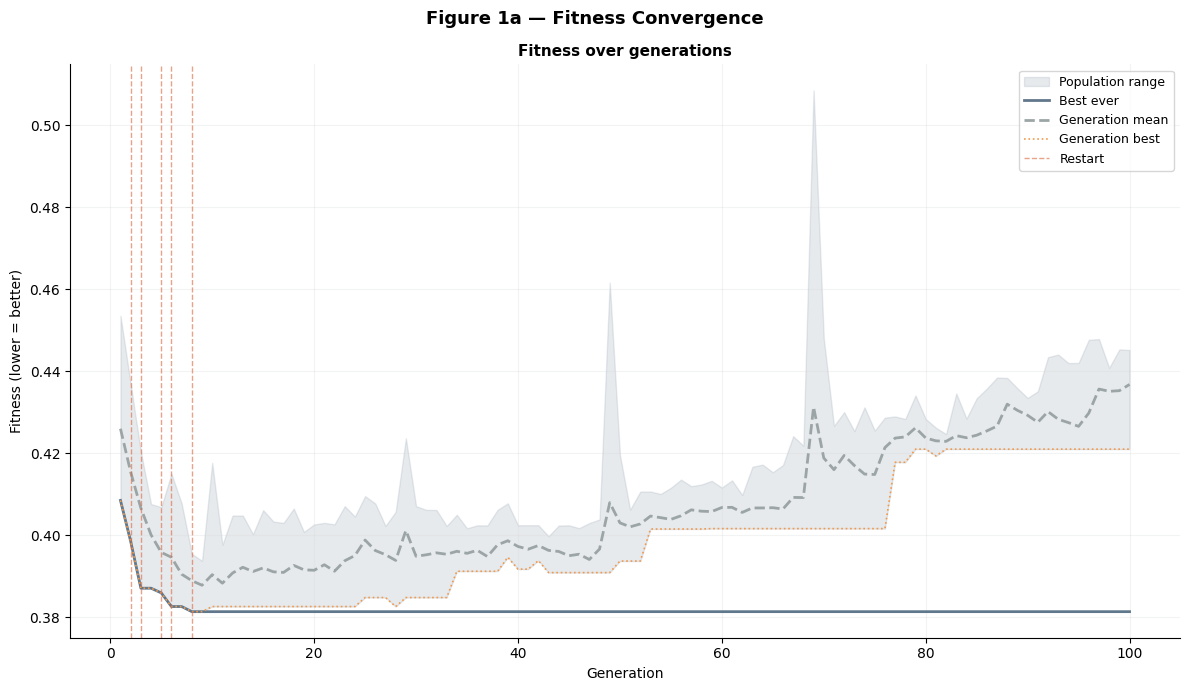

fig_conv_fitness ready


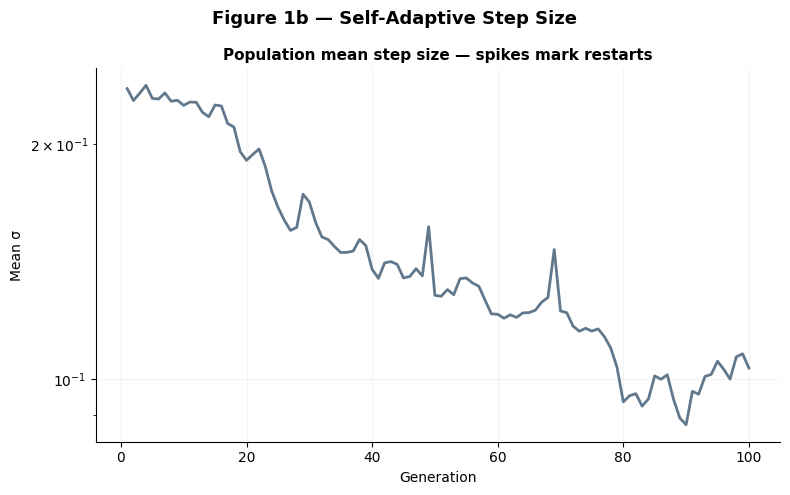

fig_conv_sigma ready


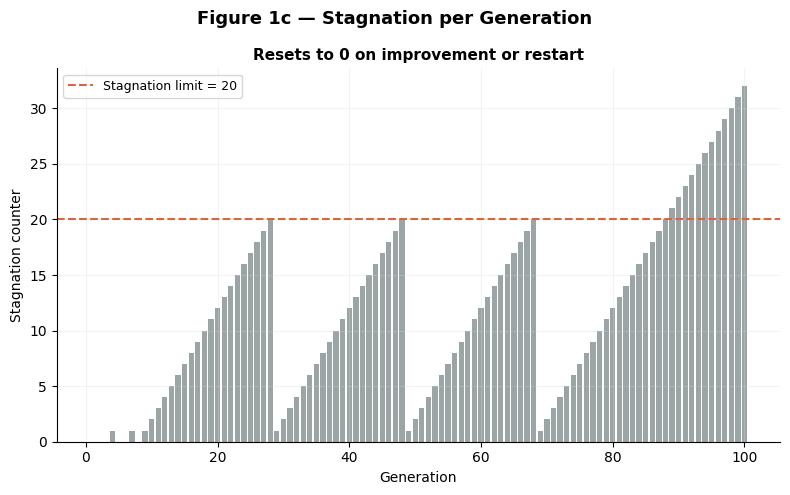

fig_conv_stagnation ready


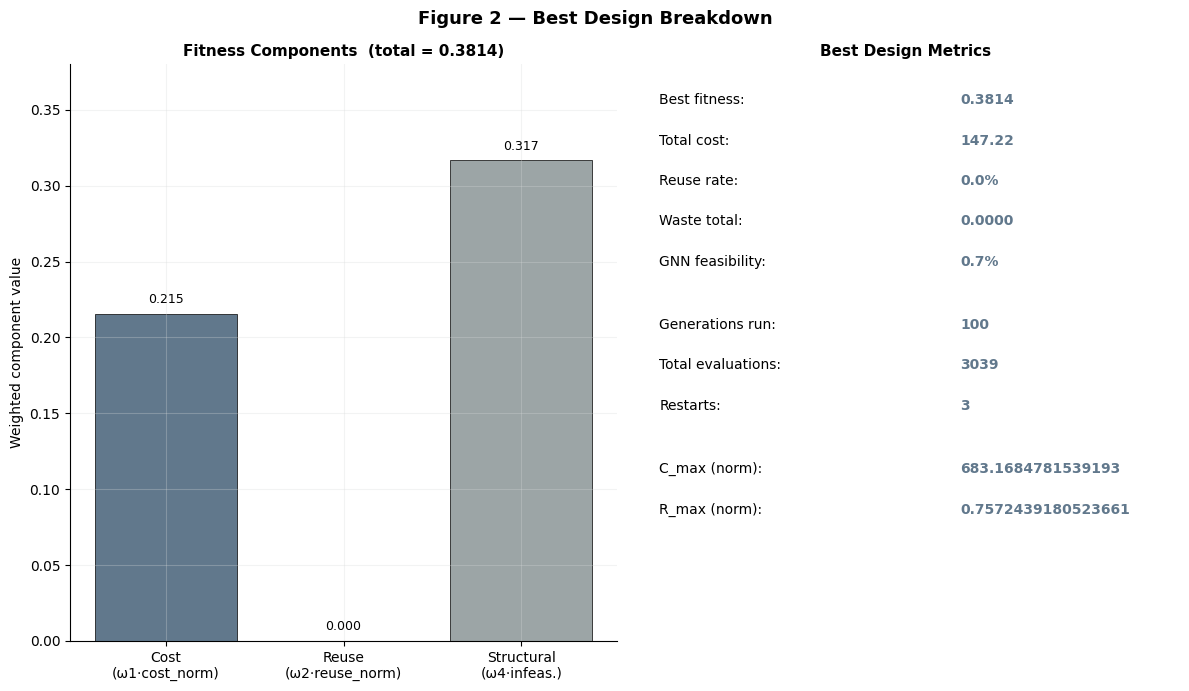

fig_best_design ready


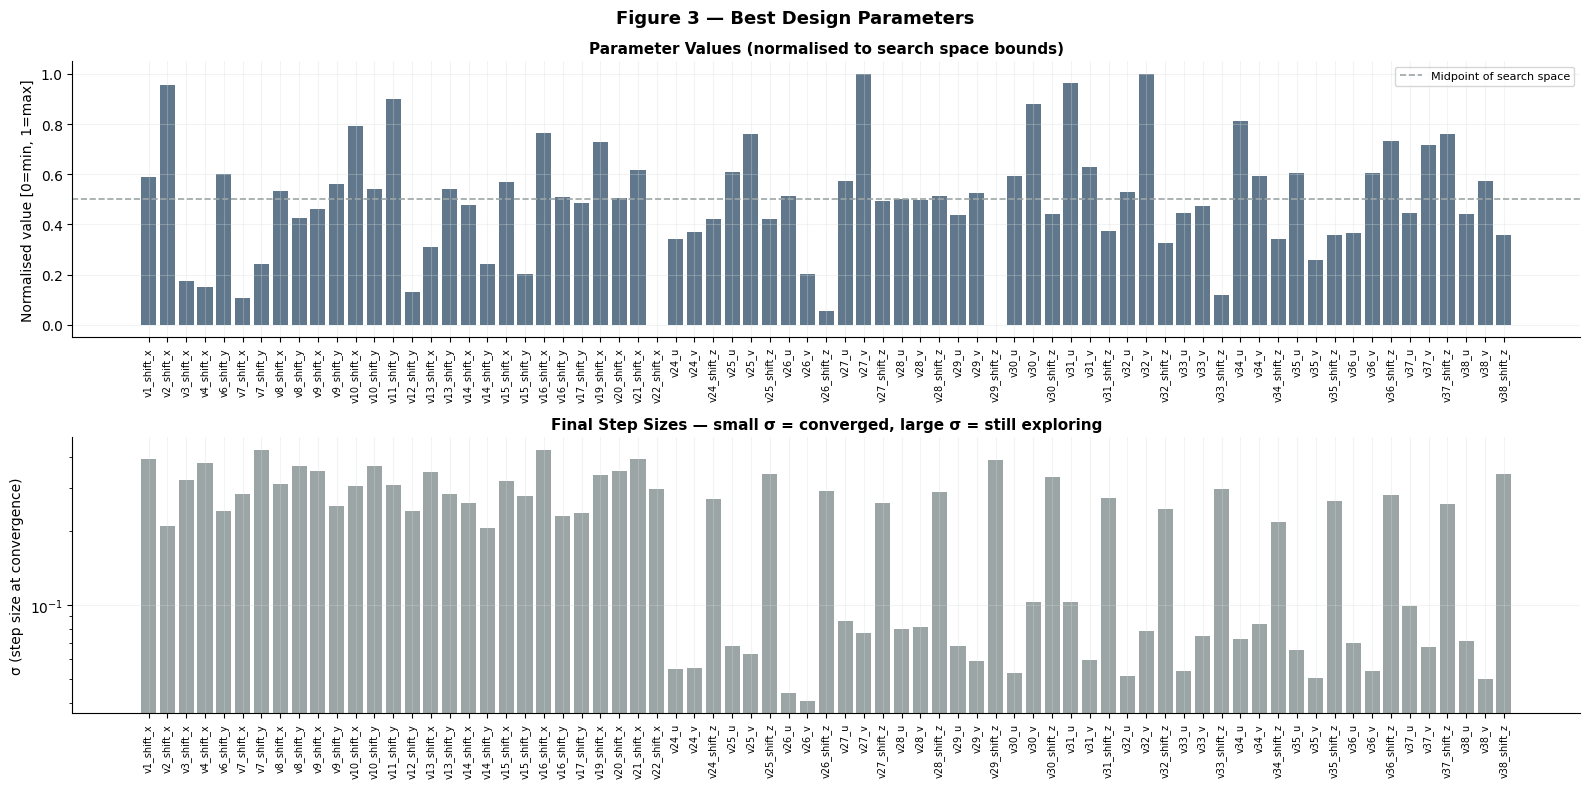

fig_params ready


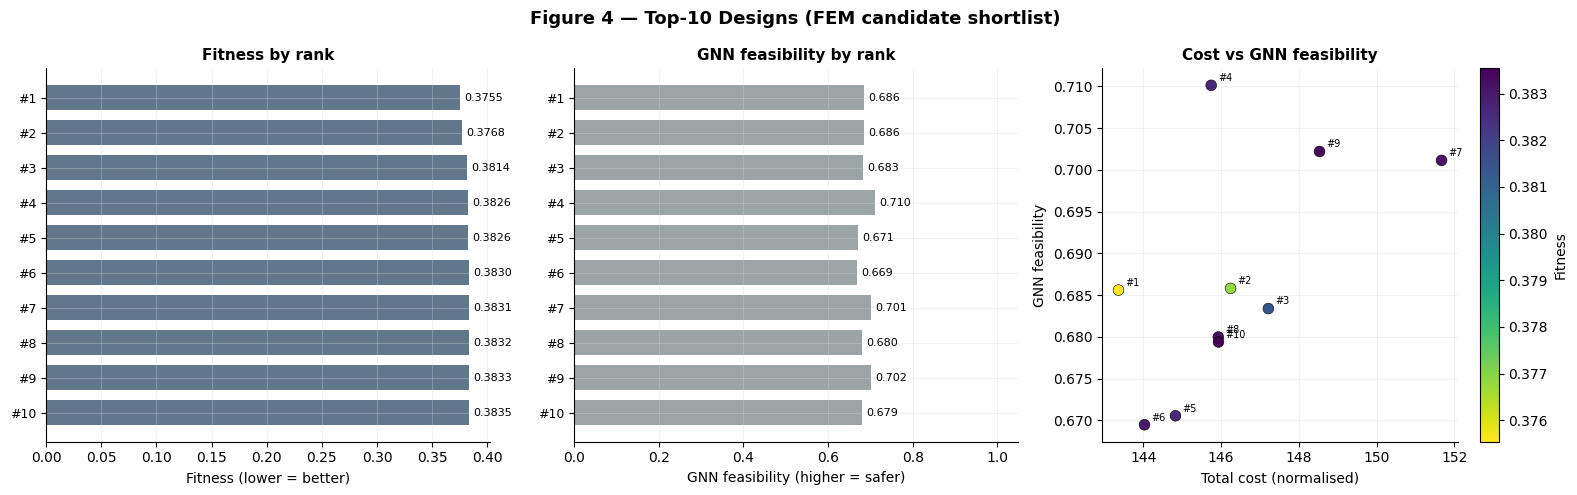

fig_top_k ready

GA RUN SUMMARY
  Generations completed:  100
  Total evaluations:      3039
  Restarts triggered:     3

  Best fitness:           0.381396
  Best total cost:        147.22
  Best reuse rate:        0.0%
  Best waste total:       0.0000
  GNN feasibility:        0.7%

  MILP status:            Optimal
  Unsafe members:         54 / 120

  Normalisation constants:  C_max=683.1684781539193  R_max=0.7572439180523661

  Top-10 designs (for FEM verification):
    # 1  fitness=0.3755  GNN=0.686  cost=143.3659  gen=9
    # 2  fitness=0.3768  GNN=0.686  cost=146.2467  gen=6
    # 3  fitness=0.3814  GNN=0.683  cost=147.2193  gen=8
    # 4  fitness=0.3826  GNN=0.710  cost=145.7496  gen=28
    # 5  fitness=0.3826  GNN=0.671  cost=144.8311  gen=6
    # 6  fitness=0.3830  GNN=0.669  cost=144.0348  gen=7
    # 7  fitness=0.3831  GNN=0.701  cost=151.6720  gen=13
    # 8  fitness=0.3832  GNN=0.680  cost=145.9330  gen=10
    # 9  fitness=0.3833  GNN=0.702  cost=148.5346  gen=19
    #10

In [6]:
import importlib
from workflows import c23_ga_analysis_export as ga_ae
importlib.reload(ga_ae)

analysis_out = ga_ae.run_analysis(
    result                 = result,
    fixed_norm_constants   = FIXED_NORMALIZATION_CONSTANTS,
    optimizer_search_space = optimizer_search_space,
    stagnation_limit       = es.config.stagnation_limit,
)

# EXPORT

In [15]:
importlib.reload(ga_ae)

export_out = ga_ae.run_export(
    analysis_out        = analysis_out,
    result              = result,
    ga_config           = GA_CONFIG,
    fixed_norm_constants= FIXED_NORMALIZATION_CONSTANTS,
    model_prefix        = MODEL_PREFIX,
    bounds_source_info  = BOUNDS_SOURCE_INFO,
    es                  = es,
)
print("Saved to:", export_out["export_dir"])

Export directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\03_ga_data\GA_20260516_212832_GEN100_EVAL3039_F0_3814
  Saved: GA_20260516_212832_GEN100_EVAL3039_F0_3814_fig1a_fitness_convergence.png
  Saved: GA_20260516_212832_GEN100_EVAL3039_F0_3814_fig1b_sigma.png
  Saved: GA_20260516_212832_GEN100_EVAL3039_F0_3814_fig1c_stagnation.png
  Saved: GA_20260516_212832_GEN100_EVAL3039_F0_3814_fig2_best_design.png
  Saved: GA_20260516_212832_GEN100_EVAL3039_F0_3814_fig3_parameters.png
  Saved: GA_20260516_212832_GEN100_EVAL3039_F0_3814_fig4_top_k_comparison.png
  Saved: GA_20260516_212832_GEN100_EVAL3039_F0_3814_best_design.json
  Saved: GA_20260516_212832_GEN100_EVAL3039_F0_3814_history.csv
  Saved: top_k_designs/GA_20260516_212832_GEN100_EVAL3039_F0_3814_top10_summary.json
  Saved: top_k_designs/GA_20260516_212832_GEN100_EVAL3039_F0_3814_top10_summary.csv
  Saved: top_k_designs/GA_20260516_212832_GEN100_EVAL3039_F0_3814_top10_vertices.csv
  Saved: top_k